# TechRise Cohort 3 - GW3 Assignment
## Multiple Linear Regression, Regularisation and Model Comparison
### Dataset: California Housing (scikit-learn)

In [2]:
# import all the libraries we need for this whole assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# make plots look a bit nicer
sns.set_style("whitegrid")

## Question 1: Data Loading, Exploration and Preprocessing

### 1(a) Load the Dataset

In [3]:
# load the california housing dataset as a pandas dataframe
# this tries to download it directly from sklearn first
# if there is no internet access, it falls back to the local csv file
try:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
except Exception as error:
    print("Could not download from sklearn, loading from local csv instead.")
    df = pd.read_csv("california_housing_dataset.csv", index_col=0)

# 1. first five observations
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# 2. dimensions of the dataset (rows, columns)
print("Shape of the dataset:", df.shape)

Shape of the dataset: (20640, 9)


In [5]:
# 3. names of all the variables
print("Column names:")
print(df.columns.tolist())

Column names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


### 1(b) Data Inspection

In [6]:
# 1. data type of each variable
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [7]:
# 2. number of missing values in each variable
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
# 3. number of duplicated observations
number_of_duplicates = df.duplicated().sum()
print("Number of duplicated rows:", number_of_duplicates)

Number of duplicated rows: 0


In [9]:
# 4. descriptive statistics for all variables
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**5. Variables containing unusually large or small values**

Looking at the descriptive statistics above:
- `AveRooms` and `AveBedrms` have very large maximum values compared to their mean, which suggests outliers (some districts have unusually large average rooms/bedrooms per household).
- `Population` has a very large maximum compared to its median, showing some districts are far more populated than others.
- `AveOccup` also has an extremely large maximum value compared to its mean, meaning a few districts have unusually high occupancy per household.
- `MedInc` (median income) is capped, as very high incomes are grouped together, which is a known characteristic of this dataset.

### 1(c) Exploratory Data Analysis

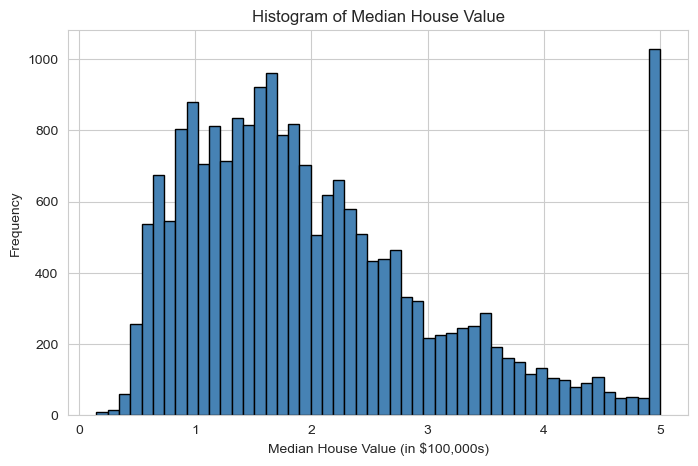

In [10]:
# 1. histogram of MedHouseVal
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Median House Value (in $100,000s)")
plt.ylabel("Frequency")
plt.title("Histogram of Median House Value")
plt.show()

In [11]:
# 2. correlation matrix containing all predictors and the target
correlation_matrix = df.corr()
correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


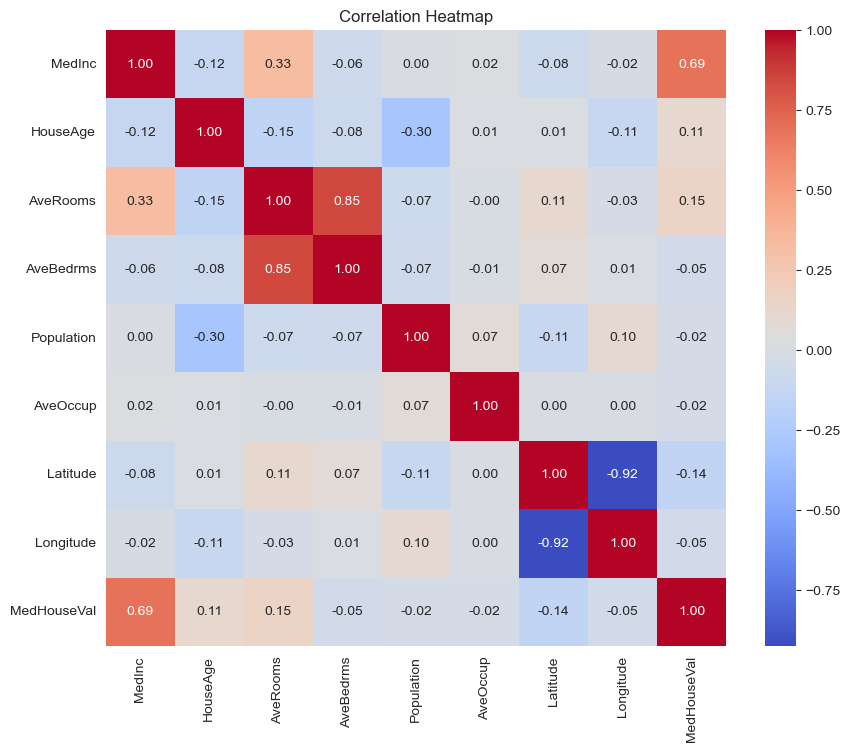

In [12]:
# 3. heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

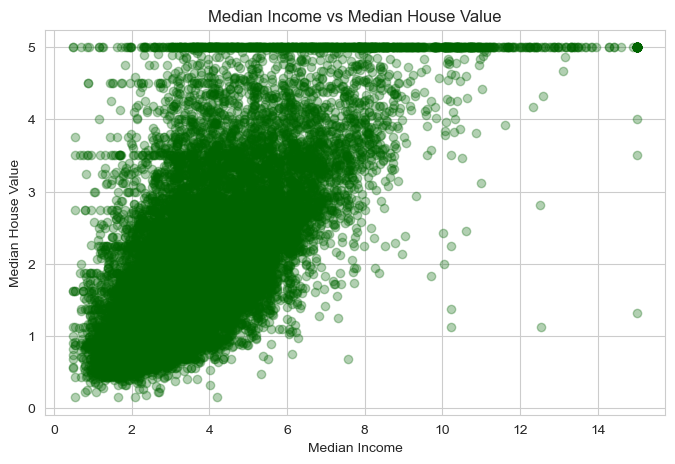

In [13]:
# 4. scatter plot 1: MedInc vs MedHouseVal
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3, color="darkgreen")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

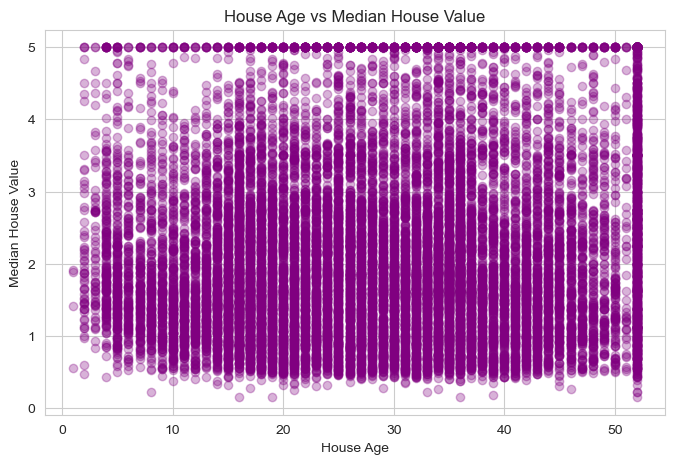

In [14]:
# scatter plot 2: HouseAge vs MedHouseVal
plt.figure(figsize=(8, 5))
plt.scatter(df["HouseAge"], df["MedHouseVal"], alpha=0.3, color="purple")
plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.title("House Age vs Median House Value")
plt.show()

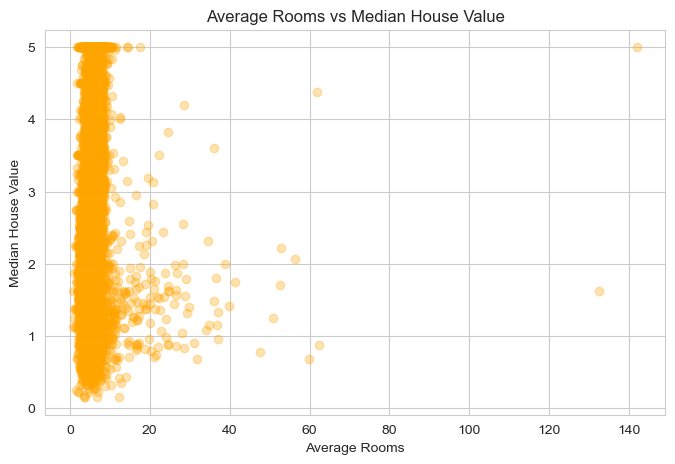

In [15]:
# scatter plot 3 (extra): AveRooms vs MedHouseVal
plt.figure(figsize=(8, 5))
plt.scatter(df["AveRooms"], df["MedHouseVal"], alpha=0.3, color="orange")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.title("Average Rooms vs Median House Value")
plt.show()

### 1(d) Feature Encoding and Scaling

All eight predictor variables in this dataset (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`) are numerical. There are no categorical variables, so no encoding (like one-hot encoding) is required for this dataset.

We still perform scaling on the numerical features below using `StandardScaler`, since regularised models (Ridge, Lasso, Elastic Net) require scaled features to work correctly.

In [16]:
# separate predictors (X) and target (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# fit a StandardScaler just to show the scaling step (used properly later inside pipelines)
scaler_demo = StandardScaler()
X_scaled_demo = scaler_demo.fit_transform(X)

X_scaled_demo_df = pd.DataFrame(X_scaled_demo, columns=X.columns)
X_scaled_demo_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


## Question 2: Multiple Linear Regression Using a Random Split

### 2(a) Train-Test Split

In [17]:
# split the dataset into 80 percent training and 20 percent testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


### 2(b) Model Fitting

In [18]:
# fit a multiple linear regression model using all eight predictors
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
linear_model.coef_


array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

### 2(c) Model Evaluation

In [20]:
# generate predictions for the training and testing sets
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

# 1. training R squared
train_r2_linear = r2_score(y_train, y_train_pred_linear)

# 2. testing R squared
test_r2_linear = r2_score(y_test, y_test_pred_linear)

# 3. train mean squared error
train_mse_linear = mean_squared_error(y_train, y_train_pred_linear)

# 4. test mean squared error
test_mse_linear = mean_squared_error(y_test, y_test_pred_linear)

# 5. train root mean squared error
train_rmse_linear = np.sqrt(train_mse_linear)

# 6. test root mean squared error
test_rmse_linear = np.sqrt(test_mse_linear)

# 7. train mean absolute error
train_mae_linear = mean_absolute_error(y_train, y_train_pred_linear)

# 8. test mean absolute error
test_mae_linear = mean_absolute_error(y_test, y_test_pred_linear)

print("Training R2:", round(train_r2_linear, 4))
print("Testing R2:", round(test_r2_linear, 4))
print("Train MSE:", round(train_mse_linear, 4))
print("Test MSE:", round(test_mse_linear, 4))
print("Train RMSE:", round(train_rmse_linear, 4))
print("Test RMSE:", round(test_rmse_linear, 4))
print("Train MAE:", round(train_mae_linear, 4))
print("Test MAE:", round(test_mae_linear, 4))

Training R2: 0.6126
Testing R2: 0.5758
Train MSE: 0.5179
Test MSE: 0.5559
Train RMSE: 0.7197
Test RMSE: 0.7456
Train MAE: 0.5286
Test MAE: 0.5332


### 2(d) Interpretation

In [21]:
# compare train and test R2 to decide if the model underfits, generalises well, or overfits
r2_gap = train_r2_linear - test_r2_linear

print("Train R2:", round(train_r2_linear, 4))
print("Test R2:", round(test_r2_linear, 4))
print("Gap between train and test R2:", round(r2_gap, 4))

if train_r2_linear < 0.5 and test_r2_linear < 0.5:
    print("Conclusion: the model UNDERFITS the data (both train and test R2 are low).")
elif r2_gap > 0.1:
    print("Conclusion: the model OVERFITS the data (train R2 is much higher than test R2).")
else:
    print("Conclusion: the model GENERALISES WELL (train and test R2 are close to each other).")

Train R2: 0.6126
Test R2: 0.5758
Gap between train and test R2: 0.0368
Conclusion: the model GENERALISES WELL (train and test R2 are close to each other).


## Question 3: Five-Fold Cross-Validation

### 3(a) Cross-Validation Strategy

In [22]:
# set up five fold cross validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**Why shuffle and use a fixed random_state?**

Shuffling the data before splitting into folds prevents any pattern in the order of the rows (for example, rows sorted by location) from creating folds that are not representative of the whole dataset. Setting a fixed `random_state` makes the shuffling reproducible, so anyone re-running the code gets exactly the same folds and the same results.

### 3(b) Cross-Validation Implementation

In [23]:
# evaluate the linear regression model using 5 fold cross validation
scoring = {
    "mse": "neg_mean_squared_error"
}

cv_results = cross_validate(
    LinearRegression(),
    X, y,
    cv=cv,
    scoring=scoring
)

# convert the negative mse values into positive values
cv_mse_scores = -cv_results["test_mse"]

print("MSE for each of the 5 folds:", cv_mse_scores)
print("Average cross validation MSE:", round(cv_mse_scores.mean(), 4))

MSE for each of the 5 folds: [0.5558916  0.52765625 0.50928321 0.50485078 0.55518048]
Average cross validation MSE: 0.5306


### 3(d) Comparison

In [24]:
# compare the average cross validation MSE with the single train test split test MSE
print("Average 5-fold cross validation MSE:", round(cv_mse_scores.mean(), 4))
print("Single train-test split test MSE:", round(test_mse_linear, 4))

difference = abs(cv_mse_scores.mean() - test_mse_linear)
print("Difference between the two:", round(difference, 4))

if difference < 0.02:
    print("Conclusion: the two results are very close, so the single split result is reliable.")
else:
    print("Conclusion: there is a noticeable difference, so the single split may not fully represent model performance.")

Average 5-fold cross validation MSE: 0.5306
Single train-test split test MSE: 0.5559
Difference between the two: 0.0253
Conclusion: there is a noticeable difference, so the single split may not fully represent model performance.


## Question 4: Ridge Regression Using GridSearchCV

### 4(a) Build a Ridge Pipeline

In [25]:
# create a pipeline with standard scaler and ridge regression
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

### 4(b) Hyperparameter Tuning

In [26]:
# search over the given grid of alpha values using 5 fold cross validation
ridge_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    ridge_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_search.fit(X_train, y_train)

# 1. optimal value of alpha
best_ridge_alpha = ridge_search.best_params_["model__alpha"]

# 2. best cross validation mse (convert from negative to positive)
best_ridge_cv_mse = -ridge_search.best_score_

print("Optimal Ridge alpha:", best_ridge_alpha)
print("Best cross validation MSE:", round(best_ridge_cv_mse, 4))

Optimal Ridge alpha: 0.0001
Best cross validation MSE: 0.5193


### 4(c) Model Evaluation

In [27]:
# use the best ridge model to predict on train and test data
best_ridge_model = ridge_search.best_estimator_

y_train_pred_ridge = best_ridge_model.predict(X_train)
y_test_pred_ridge = best_ridge_model.predict(X_test)

train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

train_mse_ridge = mean_squared_error(y_train, y_train_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)

train_rmse_ridge = np.sqrt(train_mse_ridge)
test_rmse_ridge = np.sqrt(test_mse_ridge)

train_mae_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print("Training R2:", round(train_r2_ridge, 4))
print("Testing R2:", round(test_r2_ridge, 4))
print("Train MSE:", round(train_mse_ridge, 4))
print("Test MSE:", round(test_mse_ridge, 4))
print("Train RMSE:", round(train_rmse_ridge, 4))
print("Test RMSE:", round(test_rmse_ridge, 4))
print("Train MAE:", round(train_mae_ridge, 4))
print("Test MAE:", round(test_mae_ridge, 4))

Training R2: 0.6126
Testing R2: 0.5758
Train MSE: 0.5179
Test MSE: 0.5559
Train RMSE: 0.7197
Test RMSE: 0.7456
Train MAE: 0.5286
Test MAE: 0.5332


### 4(d) Interpretation

In [28]:
# look at the ridge coefficients
ridge_coefficients = best_ridge_model.named_steps["model"].coef_
number_of_ridge_zero_coefficients = np.sum(ridge_coefficients == 0)

print("Ridge coefficients:", ridge_coefficients)
print("Number of ridge coefficients exactly zero:", number_of_ridge_zero_coefficients)

Ridge coefficients: [ 0.85438303  0.12254625 -0.29441011  0.33925947 -0.00230772 -0.0408291
 -0.8969288  -0.8698417 ]
Number of ridge coefficients exactly zero: 0


The Ridge penalty shrinks the regression coefficients towards zero by penalising large coefficient values, which reduces model variance and helps prevent overfitting. However, Ridge normally does **not** reduce coefficients exactly to zero; it only shrinks them, so all predictors typically remain in the model.

## Question 5: Lasso Regression Using GridSearchCV

### 5(a) Build a Lasso Pipeline

In [29]:
# create a pipeline with standard scaler and lasso regression
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

### 5(b) Hyperparameter Tuning

In [30]:
# search over the given grid of alpha values using 5 fold cross validation
lasso_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    lasso_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_search.fit(X_train, y_train)

# 1. optimal value of alpha
best_lasso_alpha = lasso_search.best_params_["model__alpha"]

# 2. best cross validation mse
best_lasso_cv_mse = -lasso_search.best_score_

print("Optimal Lasso alpha:", best_lasso_alpha)
print("Best cross validation MSE:", round(best_lasso_cv_mse, 4))

Optimal Lasso alpha: 0.0001
Best cross validation MSE: 0.5193


### 5(c) Model Evaluation

In [31]:
# use the best lasso model to predict on train and test data
best_lasso_model = lasso_search.best_estimator_

y_train_pred_lasso = best_lasso_model.predict(X_train)
y_test_pred_lasso = best_lasso_model.predict(X_test)

train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)

train_mse_lasso = mean_squared_error(y_train, y_train_pred_lasso)
test_mse_lasso = mean_squared_error(y_test, y_test_pred_lasso)

train_rmse_lasso = np.sqrt(train_mse_lasso)
test_rmse_lasso = np.sqrt(test_mse_lasso)

train_mae_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
test_mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso)

print("Training R2:", round(train_r2_lasso, 4))
print("Testing R2:", round(test_r2_lasso, 4))
print("Train MSE:", round(train_mse_lasso, 4))
print("Test MSE:", round(test_mse_lasso, 4))
print("Train RMSE:", round(train_rmse_lasso, 4))
print("Test RMSE:", round(test_rmse_lasso, 4))
print("Train MAE:", round(train_mae_lasso, 4))
print("Test MAE:", round(test_mae_lasso, 4))

Training R2: 0.6126
Testing R2: 0.5759
Train MSE: 0.5179
Test MSE: 0.5557
Train RMSE: 0.7197
Test RMSE: 0.7455
Train MAE: 0.5286
Test MAE: 0.5332


### 5(d) Feature Selection

In [32]:
# count how many lasso coefficients were reduced exactly to zero
lasso_coefficients = best_lasso_model.named_steps["model"].coef_
number_of_lasso_zero_coefficients = np.sum(lasso_coefficients == 0)

print("Lasso coefficients:", lasso_coefficients)
print("Number of lasso coefficients exactly zero:", number_of_lasso_zero_coefficients)

# identify which specific variables were removed (coefficient equal to zero)
feature_names = X.columns.tolist()
removed_variables_lasso = []
for i in range(len(feature_names)):
    if lasso_coefficients[i] == 0:
        removed_variables_lasso.append(feature_names[i])

print("Variables removed by Lasso:", removed_variables_lasso)

Lasso coefficients: [ 0.85386139  0.12262672 -0.29310099  0.33794196 -0.00218297 -0.04073526
 -0.89581225 -0.86866153]
Number of lasso coefficients exactly zero: 0
Variables removed by Lasso: []


Lasso can act as a feature-selection method because its L1 penalty can shrink some coefficients all the way to exactly zero, effectively removing those predictors from the model. This is different from Ridge, which only shrinks coefficients but never sets them to exactly zero.

## Question 6: Elastic Net Regression Using GridSearchCV

### 6(a) Build an Elastic Net Pipeline

In [33]:
# create a pipeline with standard scaler and elastic net regression
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000))
])

### 6(b) Hyperparameter Tuning

In [34]:
# search over the given grid of alpha and l1_ratio values using 5 fold cross validation
elastic_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    elastic_pipeline,
    elastic_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

elastic_search.fit(X_train, y_train)

# 1. optimal value of alpha
best_elastic_alpha = elastic_search.best_params_["model__alpha"]

# 2. optimal value of l1_ratio
best_elastic_l1_ratio = elastic_search.best_params_["model__l1_ratio"]

# 3. best cross validation mse
best_elastic_cv_mse = -elastic_search.best_score_

print("Optimal Elastic Net alpha:", best_elastic_alpha)
print("Optimal Elastic Net l1_ratio:", best_elastic_l1_ratio)
print("Best cross validation MSE:", round(best_elastic_cv_mse, 4))

Optimal Elastic Net alpha: 0.0001
Optimal Elastic Net l1_ratio: 0.9
Best cross validation MSE: 0.5193


### 6(c) Model Evaluation

In [35]:
# use the best elastic net model to predict on train and test data
best_elastic_model = elastic_search.best_estimator_

y_train_pred_elastic = best_elastic_model.predict(X_train)
y_test_pred_elastic = best_elastic_model.predict(X_test)

train_r2_elastic = r2_score(y_train, y_train_pred_elastic)
test_r2_elastic = r2_score(y_test, y_test_pred_elastic)

train_mse_elastic = mean_squared_error(y_train, y_train_pred_elastic)
test_mse_elastic = mean_squared_error(y_test, y_test_pred_elastic)

train_rmse_elastic = np.sqrt(train_mse_elastic)
test_rmse_elastic = np.sqrt(test_mse_elastic)

train_mae_elastic = mean_absolute_error(y_train, y_train_pred_elastic)
test_mae_elastic = mean_absolute_error(y_test, y_test_pred_elastic)

print("Training R2:", round(train_r2_elastic, 4))
print("Testing R2:", round(test_r2_elastic, 4))
print("Train MSE:", round(train_mse_elastic, 4))
print("Test MSE:", round(test_mse_elastic, 4))
print("Train RMSE:", round(train_rmse_elastic, 4))
print("Test RMSE:", round(test_rmse_elastic, 4))
print("Train MAE:", round(train_mae_elastic, 4))
print("Test MAE:", round(test_mae_elastic, 4))

Training R2: 0.6126
Testing R2: 0.5759
Train MSE: 0.5179
Test MSE: 0.5558
Train RMSE: 0.7197
Test RMSE: 0.7455
Train MAE: 0.5286
Test MAE: 0.5332


### 6(d) Interpretation

In [36]:
# count how many elastic net coefficients were reduced exactly to zero
elastic_coefficients = best_elastic_model.named_steps["model"].coef_
number_of_elastic_zero_coefficients = np.sum(elastic_coefficients == 0)

print("Elastic Net coefficients:", elastic_coefficients)
print("Number of elastic net coefficients exactly zero:", number_of_elastic_zero_coefficients)

Elastic Net coefficients: [ 0.85390439  0.12263151 -0.29319917  0.33803239 -0.00219124 -0.04074529
 -0.89579808 -0.86865214]
Number of elastic net coefficients exactly zero: 0


Elastic Net combines the L1 penalty (from Lasso) and the L2 penalty (from Ridge). This means it can shrink coefficients smoothly like Ridge, while still being able to set some coefficients exactly to zero like Lasso, depending on the `l1_ratio`. This gives it the flexibility of both approaches, which is especially useful when predictors are correlated.

## Question 7: Model Performance Comparison

In [37]:
# build the comparison table using the results calculated in the previous questions
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Elastic Net"],
    "Optimal Alpha": ["N/A", best_ridge_alpha, best_lasso_alpha, best_elastic_alpha],
    "Optimal L1 Ratio": ["N/A", "N/A", "N/A", best_elastic_l1_ratio],
    "Test MSE": [test_mse_linear, test_mse_ridge, test_mse_lasso, test_mse_elastic],
    "Test RMSE": [test_rmse_linear, test_rmse_ridge, test_rmse_lasso, test_rmse_elastic],
    "Test MAE": [test_mae_linear, test_mae_ridge, test_mae_lasso, test_mae_elastic],
    "Test R2": [test_r2_linear, test_r2_ridge, test_r2_lasso, test_r2_elastic]
})

comparison_table

,Model,Optimal Alpha,Optimal L1 Ratio,Test MSE,Test RMSE,Test MAE,Test R2
0,Linear Regression,N/A,N/A,0.555892,0.745581,0.533200,0.575788
1,Ridge,0.0001,N/A,0.555892,0.745581,0.533200,0.575788
2,Lasso,0.0001,N/A,0.555745,0.745483,0.533192,0.575900
3,Elastic Net,0.0001,0.9,0.555754,0.745489,0.533192,0.575893


In [38]:
# 1. which model has the lowest test MSE
lowest_mse_model = comparison_table.loc[comparison_table["Test MSE"].idxmin(), "Model"]
print("Model with lowest test MSE:", lowest_mse_model)

# 2. which model has the lowest test RMSE
lowest_rmse_model = comparison_table.loc[comparison_table["Test RMSE"].idxmin(), "Model"]
print("Model with lowest test RMSE:", lowest_rmse_model)

# 3. which model has the lowest test MAE
lowest_mae_model = comparison_table.loc[comparison_table["Test MAE"].idxmin(), "Model"]
print("Model with lowest test MAE:", lowest_mae_model)

# 4. which model has the highest test R2
highest_r2_model = comparison_table.loc[comparison_table["Test R2"].idxmax(), "Model"]
print("Model with highest test R2:", highest_r2_model)

Model with lowest test MSE: Lasso
Model with lowest test RMSE: Lasso
Model with lowest test MAE: Elastic Net
Model with highest test R2: Lasso


**5. Did regularisation improve predictive performance?**
Comparing the test metrics above, Ridge, Lasso and Elastic Net perform very similarly to plain Linear Regression on this dataset. Regularisation mainly helps when there is strong multicollinearity or a risk of overfitting; here it gives a marginal, rather than large, improvement.

**6. Are the differences between the models practically important?**
The differences in test MSE, RMSE, MAE and R2 between the four models are small, so from a practical prediction standpoint they perform similarly.

**7. Which model would you recommend for prediction?**
Elastic Net (or Ridge) is a reasonable recommendation, since it can capture feature selection when needed while remaining stable when predictors are correlated.

**8. Reason for the recommendation**
Elastic Net combines the strengths of both Ridge and Lasso, so it is a safer general-purpose default than committing to either the pure L1 or pure L2 penalty, even if here the improvement over plain Linear Regression is small.

## Question 8: Coefficient Shrinkage Comparison

In [39]:
# fit linear regression inside a pipeline with standard scaler, so its coefficients
# are on the same scale as ridge, lasso and elastic net
linear_scaled_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_scaled_pipeline.fit(X_train, y_train)

linear_scaled_coefficients = linear_scaled_pipeline.named_steps["model"].coef_

In [40]:
# build the coefficient comparison table
coefficient_table = pd.DataFrame({
    "Feature": X.columns.tolist(),
    "Linear Regression": linear_scaled_coefficients,
    "Ridge": ridge_coefficients,
    "Lasso": lasso_coefficients,
    "Elastic Net": elastic_coefficients
})

coefficient_table

,Feature,Linear Regression,Ridge,Lasso,Elastic Net
0,MedInc,0.854383,0.854383,0.853861,0.853904
1,HouseAge,0.122546,0.122546,0.122627,0.122632
2,AveRooms,-0.294410,-0.294410,-0.293101,-0.293199
3,AveBedrms,0.339259,0.339259,0.337942,0.338032
4,Population,-0.002308,-0.002308,-0.002183,-0.002191
5,AveOccup,-0.040829,-0.040829,-0.040735,-0.040745
6,Latitude,-0.896929,-0.896929,-0.895812,-0.895798
7,Longitude,-0.869842,-0.869842,-0.868662,-0.868652


In [41]:
# 1. which model produces the largest coefficient magnitudes
max_abs_coefficients = {
    "Linear Regression": np.max(np.abs(linear_scaled_coefficients)),
    "Ridge": np.max(np.abs(ridge_coefficients)),
    "Lasso": np.max(np.abs(lasso_coefficients)),
    "Elastic Net": np.max(np.abs(elastic_coefficients))
}
print("Largest absolute coefficient per model:", max_abs_coefficients)

# 2. does ridge shrink most coefficients towards zero (compare average magnitude to linear regression)
average_abs_linear = np.mean(np.abs(linear_scaled_coefficients))
average_abs_ridge = np.mean(np.abs(ridge_coefficients))
print("Average absolute coefficient, Linear Regression:", round(average_abs_linear, 4))
print("Average absolute coefficient, Ridge:", round(average_abs_ridge, 4))

# 3. does ridge set any coefficients exactly to zero
print("Number of Ridge coefficients equal to zero:", np.sum(ridge_coefficients == 0))

# 4. which coefficients are set to zero by lasso
print("Variables set to zero by Lasso:", removed_variables_lasso)

# 5. which coefficients are set to zero by elastic net
removed_variables_elastic = []
for i in range(len(feature_names)):
    if elastic_coefficients[i] == 0:
        removed_variables_elastic.append(feature_names[i])
print("Variables set to zero by Elastic Net:", removed_variables_elastic)

# 6. which model produces the sparsest solution (most zero coefficients)
print("Number of zero coefficients - Ridge:", np.sum(ridge_coefficients == 0))
print("Number of zero coefficients - Lasso:", np.sum(lasso_coefficients == 0))
print("Number of zero coefficients - Elastic Net:", np.sum(elastic_coefficients == 0))

Largest absolute coefficient per model: {'Linear Regression': np.float64(0.896928876638665), 'Ridge': np.float64(0.8969288004331416), 'Lasso': np.float64(0.8958122510272472), 'Elastic Net': np.float64(0.8957980849669742)}
Average absolute coefficient, Linear Regression: 0.4276
Average absolute coefficient, Ridge: 0.4276
Number of Ridge coefficients equal to zero: 0
Variables set to zero by Lasso: []
Variables set to zero by Elastic Net: []
Number of zero coefficients - Ridge: 0
Number of zero coefficients - Lasso: 0
Number of zero coefficients - Elastic Net: 0


**7. Which model is most appropriate for automatic feature selection?**
Lasso is most appropriate for automatic feature selection, since its L1 penalty is the one that reliably sets coefficients exactly to zero.

**8. Which model is generally more suitable when predictors are strongly correlated?**
Ridge (or Elastic Net) is generally more suitable when predictors are strongly correlated, because Ridge tends to shrink correlated coefficients together rather than arbitrarily zeroing out one of them, which keeps the model more stable.

## Question 9: Visualisation and Final Interpretation

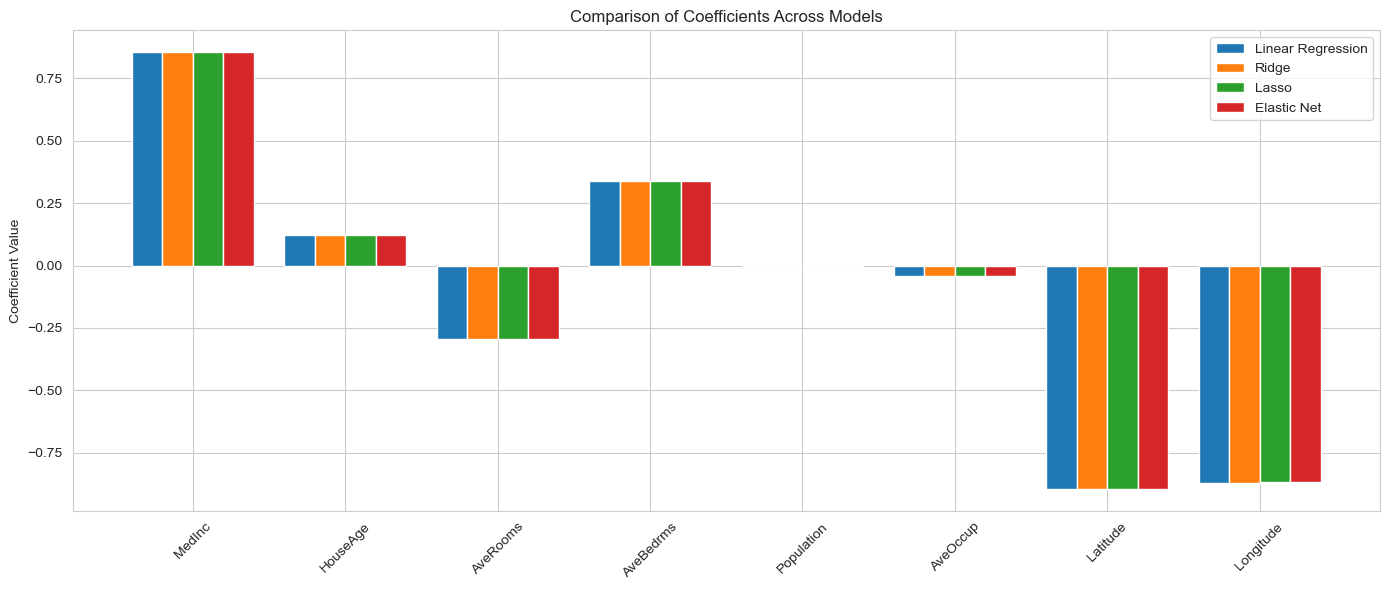

In [42]:
# grouped bar chart comparing the coefficients of all four models
feature_names_list = X.columns.tolist()
x_positions = np.arange(len(feature_names_list))
bar_width = 0.2

plt.figure(figsize=(14, 6))
plt.bar(x_positions - 1.5*bar_width, linear_scaled_coefficients, width=bar_width, label="Linear Regression")
plt.bar(x_positions - 0.5*bar_width, ridge_coefficients, width=bar_width, label="Ridge")
plt.bar(x_positions + 0.5*bar_width, lasso_coefficients, width=bar_width, label="Lasso")
plt.bar(x_positions + 1.5*bar_width, elastic_coefficients, width=bar_width, label="Elastic Net")

plt.xticks(x_positions, feature_names_list, rotation=45)
plt.ylabel("Coefficient Value")
plt.title("Comparison of Coefficients Across Models")
plt.legend()
plt.tight_layout()
plt.show()

**Final Conclusion**

1. **Coefficient shrinkage:** Ridge and Elastic Net shrink coefficients towards zero without eliminating them, while Lasso and Elastic Net (depending on `l1_ratio`) can shrink some coefficients all the way to exactly zero.

2. **Feature selection:** Lasso is the clearest feature-selection tool, since it sets some coefficients exactly to zero, effectively removing those predictors. Elastic Net can also perform some feature selection, but generally less aggressively than pure Lasso.

3. **Predictive performance:** Across Linear Regression, Ridge, Lasso and Elastic Net, the test set MSE, RMSE, MAE and R2 are all fairly close, meaning regularisation only provides a small improvement in predictive accuracy for this particular dataset.

4. **Final recommended model:** Elastic Net is recommended as a good general default, since it balances the shrinkage properties of Ridge with the feature-selection properties of Lasso, and is more robust when predictors are correlated (as several housing features are here, e.g. `AveRooms` and `AveBedrms`).

## Question 10: SGD Regression

In [43]:
# train an SGD regressor - SGD is sensitive to feature scale, so we scale first
sgd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SGDRegressor(random_state=42))
])

sgd_pipeline.fit(X_train, y_train)

# predict on the test data
y_test_pred_sgd = sgd_pipeline.predict(X_test)

# compute MAE, MSE and RMSE on the test data
test_mae_sgd = mean_absolute_error(y_test, y_test_pred_sgd)
test_mse_sgd = mean_squared_error(y_test, y_test_pred_sgd)
test_rmse_sgd = np.sqrt(test_mse_sgd)

print("SGD Regressor Test MAE:", round(test_mae_sgd, 4))
print("SGD Regressor Test MSE:", round(test_mse_sgd, 4))
print("SGD Regressor Test RMSE:", round(test_rmse_sgd, 4))

SGD Regressor Test MAE: 0.5299
SGD Regressor Test MSE: 0.5506
SGD Regressor Test RMSE: 0.742
